# Laboratorio 3: Evaluación de Riesgo Financiero para Préstamos (Loan.csv)
## Modelos de Regresión en PyTorch con Optimizador Adam y Ecuación de la Normal

**Objetivo:** Predecir el puntaje de riesgo crediticio (**RiskScore**, variable continua $y$) a partir de las características financieras, laborales y personales de los solicitantes de crédito.

Para la determinación de los parámetros $\theta$, se implementan y comparan tres enfoques construidos en **PyTorch**:
1. **Regresión Lineal Multivariable** (optimizada mediante Descenso por Gradiente con **Adam**).
2. **Regresión Polinómica Grado 2** (características cuadráticas optimizadas con **Adam** y regularización).
3. **Ecuación de la Normal** (solución analítica exacta calculada mediante álgebra lineal de tensores en GPU/CPU).

Se incluyen objetos de manejo de datos (`Dataset` y `DataLoader`), regularización (`Dropout` y `Weight Decay`), puntos de control (*Checkpoints* y *Early Stopping*), gráficas de costo y evaluación, y validación con más de 100 predicciones sobre el conjunto de prueba.

In [ ]:
# Esta celda importa librerías para manejo de datos, álgebra lineal y gráficos en PyTorch.
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# Objetos centrales de PyTorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import PolynomialFeatures


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo en encontrado: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}')
print(f'Dispositivo en uso: {device}')

In [57]:
# 1. Definición de la clase Dataset (hereda de torch.utils.data.Dataset)
# Encapsula las características X y la variable objetivo y como tensores de PyTorch.
class LoanRiskDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

### Carga y Preprocesamiento del Dataset
Se carga el dataset `Loan.csv` (20,000 registros). 
- Se limpian y codifican las variables categóricas de texto (`EmploymentStatus`, `EducationLevel`, `MaritalStatus`, `HomeOwnershipStatus`, `LoanPurpose`) mediante `pd.factorize`.
- Se extrae la variable objetivo continua `RiskScore` ($y$).
- Se descartan identificadores o etiquetas de clasificación (`ApplicationDate`, `LoanApproved`).
- Se divide el dataset en 80% Entrenamiento (16,000 muestras) y 20% Prueba (4,000 muestras) con semilla fija reproducible (`seed=42`).

In [58]:
# Esta celda define la ruta del dataset local.
dataset = r'E:\USFX\7mo Semestre\Inteligencia Artificial\Laboratorios\Laboratorio3\Loan.csv'
print(f'Archivo a usar: {os.path.abspath(dataset)}')

Archivo a usar: E:\USFX\7mo Semestre\Inteligencia Artificial\Laboratorios\Laboratorio3\Loan.csv


In [59]:
# Carga del conjunto de datos con pandas
df = pd.read_csv(dataset)

# Limpieza y conversión de columnas de texto categóricas a valores numéricos
cols_texto = ['EmploymentStatus', 'EducationLevel', 'MaritalStatus', 'HomeOwnershipStatus', 'LoanPurpose']
for col in cols_texto:
    df[col] = df[col].astype(str).str.strip()
    df[col], categorias = pd.factorize(df[col])
    print(f"Columna '{col}' codificada: {list(categorias)}")

# Extracción de la variable objetivo (y): RiskScore
y = df['RiskScore'].values.astype(float)

# Eliminación de columnas no aplicables para regresión continua
columnas_excluidas = ['ApplicationDate', 'LoanApproved', 'RiskScore']
df_X = df.drop(columns=columnas_excluidas)
X_original = df_X.values.astype(float)

# División reproducible: 80% entrenamiento (16,000) y 20% prueba (4,000)
np.random.seed(42)
m_total = X_original.shape[0]
indices = np.random.permutation(m_total)

corte = int(0.8 * m_total)
idx_train, idx_test = indices[:corte], indices[corte:]

X_train = X_original[idx_train]
X_test = X_original[idx_test]
y_train = y[idx_train]
y_test = y[idx_test]

print(f"\nTotal de muestras: {m_total} filas, {X_original.shape[1]} propiedades de entrada")
print(f"Muestras de Entrenamiento: {X_train.shape[0]} filas")
print(f"Muestras de Prueba (Validación): {X_test.shape[0]} filas (cumple con >= 100 predicciones)")

Columna 'EmploymentStatus' codificada: ['Employed', 'Self-Employed', 'Unemployed']
Columna 'EducationLevel' codificada: ['Master', 'Associate', 'Bachelor', 'High School', 'Doctorate']
Columna 'MaritalStatus' codificada: ['Married', 'Single', 'Divorced', 'Widowed']
Columna 'HomeOwnershipStatus' codificada: ['Own', 'Mortgage', 'Rent', 'Other']
Columna 'LoanPurpose' codificada: ['Home', 'Debt Consolidation', 'Education', 'Other', 'Auto']

Total de muestras: 20000 filas, 33 propiedades de entrada
Muestras de Entrenamiento: 16000 filas
Muestras de Prueba (Validación): 4000 filas (cumple con >= 100 predicciones)


In [60]:
# 1. Normalización z-score para características lineales
mu_lin = X_train.mean(axis=0)
std_lin = X_train.std(axis=0)
std_lin[std_lin == 0] = 1.0

X_train_norm = (X_train - mu_lin) / std_lin
X_test_norm = (X_test - mu_lin) / std_lin

# 2. Generación de características polinómicas de grado 2 (interacciones cuadráticas)
pf = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly_raw = pf.fit_transform(X_train)
X_test_poly_raw = pf.transform(X_test)

# Normalización z-score para características polinómicas
mu_poly = X_train_poly_raw.mean(axis=0)
std_poly = X_train_poly_raw.std(axis=0)
std_poly[std_poly == 0] = 1.0

X_train_poly_norm = (X_train_poly_raw - mu_poly) / std_poly
X_test_poly_norm = (X_test_poly_raw - mu_poly) / std_poly

print(f"Dimensiones X lineal: {X_train_norm.shape[1]} propiedades")
print(f"Dimensiones X polinómico (grado 2): {X_train_poly_norm.shape[1]} propiedades")

Dimensiones X lineal: 33 propiedades
Dimensiones X polinómico (grado 2): 594 propiedades


In [61]:
# Instanciamos los Datasets y DataLoaders de PyTorch
batch_size = 128

# DataLoaders para el modelo Lineal
train_dataset_lin = LoanRiskDataset(X_train_norm, y_train)
test_dataset_lin = LoanRiskDataset(X_test_norm, y_test)
train_loader_lin = DataLoader(train_dataset_lin, batch_size=batch_size, shuffle=True)
test_loader_lin = DataLoader(test_dataset_lin, batch_size=batch_size, shuffle=False)

# DataLoaders para el modelo Polinómico
train_dataset_poly = LoanRiskDataset(X_train_poly_norm, y_train)
test_dataset_poly = LoanRiskDataset(X_test_poly_norm, y_test)
train_loader_poly = DataLoader(train_dataset_poly, batch_size=batch_size, shuffle=True)
test_loader_poly = DataLoader(test_dataset_poly, batch_size=batch_size, shuffle=False)

print(f"Batches de entrenamiento por época: {len(train_loader_lin)}")
print(f"Batches de prueba por época: {len(test_loader_lin)}")

Batches de entrenamiento por época: 125
Batches de prueba por época: 32


In [62]:
# Verificación de integridad de datos y configuración del dispositivo GPU/CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo de cómputo en uso: {device}')
print(f'Valores NaN en X_train: {np.isnan(X_train).sum()}')
print(f'Valores NaN en X_test:  {np.isnan(X_test).sum()}')
print(f'Dimensiones finales X_train: {X_train.shape}, y_train: {y_train.shape}')

criterion = torch.nn.MSELoss()
var_y_train = float(np.var(y_train))
var_y_test = float(np.var(y_test))

Dispositivo de cómputo en uso: cuda
Valores NaN en X_train: 0
Valores NaN en X_test:  0
Dimensiones finales X_train: (16000, 33), y_train: (16000,)


---
## Modelo 1: Regresión Lineal Multivariable (PyTorch con Optimizador Adam)
Se entrena un modelo lineal multivariable paramétrico ($y = X\theta + b$) implementado con tensores y optimizado mediante **Adam**.
- **Regularización L2 (Weight Decay):** Penaliza pesos excesivos ($10^{-4}$).
- **Early Stopping (Paciencia = 20):** Detiene el bucle si la pérdida en Test no mejora en 20 épocas consecutivas, previniendo el sobreajuste (*overfitting*).
- **Checkpointing:** Se guarda automáticamente el estado óptimo en `best_model_lineal_lab3.pt`.

=== ENTRENANDO MODELO 1: REGRESIÓN LINEAL MULTIVARIABLE (ADAM) ===
Época 001/100 - Train MSE: 21.9891 | Test MSE: 13.4915 (Mejor modelo guardado)
Época 010/100 - Train MSE: 13.6896 | Test MSE: 12.9694 
Época 020/100 - Train MSE: 13.6738 | Test MSE: 12.9356 
Época 030/100 - Train MSE: 13.6821 | Test MSE: 13.3356 

--> Early Stopping activado en Época 36: detención automática para evitar sobreajuste.

----------------- RESULTADOS EN TEST (MODELO 1: LINEAL ADAM) -----------------
Error Cuadrático Medio (MSE): 12.7936
Raíz del Error Cuadrático Medio (RMSE): ±3.5768
Error Absoluto Medio (MAE): 2.8217
Error Porcentual Medio (MAPE): 5.95%
Precisión del Modelo (R²): 78.48%
-------------------------------------------------------------------------------



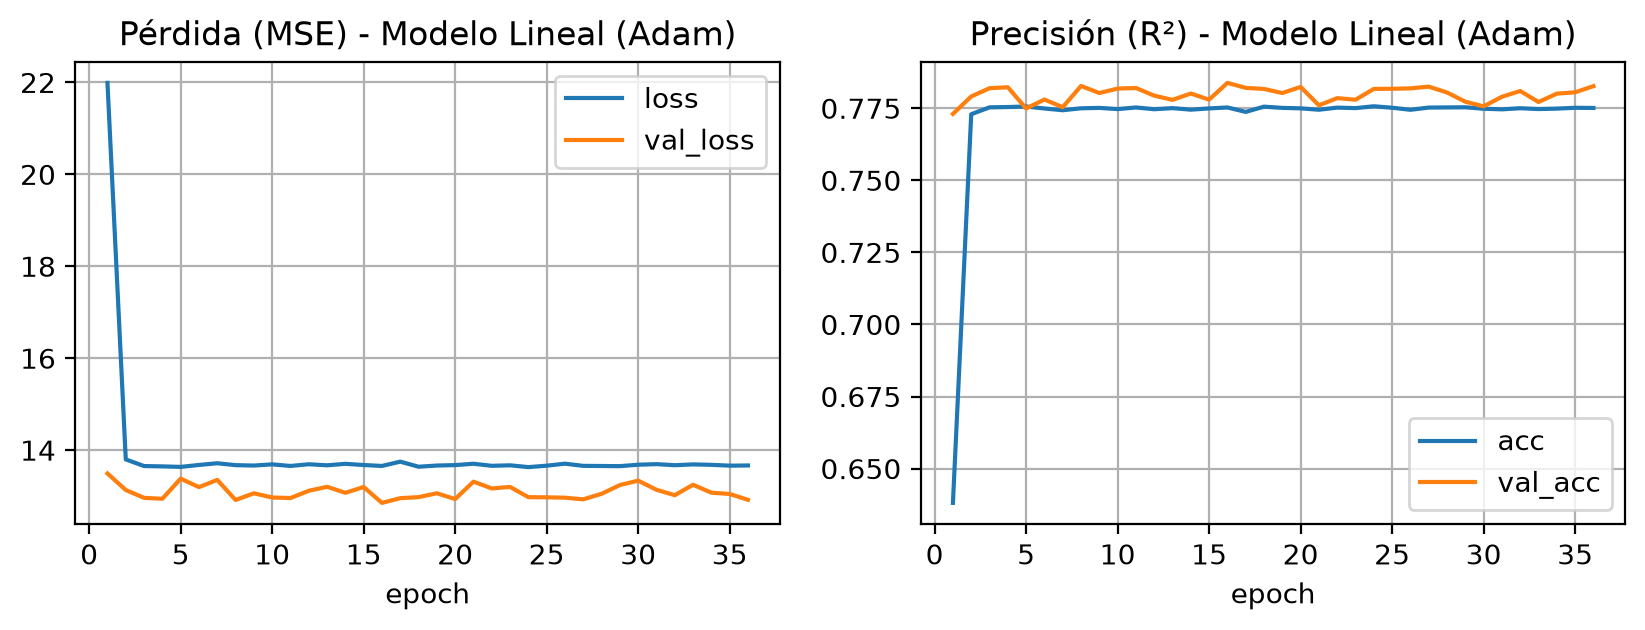

In [63]:
# ====================================================================
# MODELO 1: REGRESIÓN LINEAL MULTIVARIABLE (ADAM + REGULARIZACIÓN)
# ====================================================================
BEST_MODEL_LIN_PATH = 'best_model_lineal_lab3.pt'
D_in_lin = X_train_norm.shape[1]

# Definición del modelo lineal en PyTorch
model_lin = torch.nn.Sequential(
    torch.nn.Linear(D_in_lin, 1)
).to(device)

# Inicialización estable del sesgo con la media observada de RiskScore
with torch.no_grad():
    model_lin[0].bias.fill_(float(np.mean(y_train)))

# Optimizador Adam con Weight Decay (Regularización L2)
optimizer_lin = torch.optim.Adam(model_lin.parameters(), lr=0.03, weight_decay=1e-4)

epochs = 100
patience = 20
patience_counter = 0
best_val_loss_lin = float('inf')

loss_history_train_lin = []
loss_history_val_lin = []
hist_lin = {'epoch': [], 'loss': [], 'val_loss': [], 'acc': [], 'val_acc': []}

print('=== ENTRENANDO MODELO 1: REGRESIÓN LINEAL MULTIVARIABLE (ADAM) ===')
for epoch in range(1, epochs + 1):
    model_lin.train()
    batch_losses = []
    for x_b, y_b in train_loader_lin:
        x_b, y_b = x_b.to(device), y_b.to(device)
        
        optimizer_lin.zero_grad()
        pred = model_lin(x_b)
        loss = criterion(pred, y_b)
        loss.backward()
        optimizer_lin.step()
        batch_losses.append(loss.item())
        
    train_loss = float(np.mean(batch_losses))
    loss_history_train_lin.append(train_loss)

    # Modo evaluación en conjunto de prueba
    model_lin.eval()
    val_losses = []
    with torch.no_grad():
        for x_val, y_val in test_loader_lin:
            x_val, y_val = x_val.to(device), y_val.to(device)
            val_loss = criterion(model_lin(x_val), y_val)
            val_losses.append(val_loss.item())
            
    val_loss = float(np.mean(val_losses))
    loss_history_val_lin.append(val_loss)

    # Métricas de precisión R² (coeficiente de determinación)
    train_acc = max(0.0, 1.0 - (train_loss / var_y_train))
    val_acc = max(0.0, 1.0 - (val_loss / var_y_test))

    hist_lin['epoch'].append(epoch)
    hist_lin['loss'].append(train_loss)
    hist_lin['val_loss'].append(val_loss)
    hist_lin['acc'].append(train_acc)
    hist_lin['val_acc'].append(val_acc)

    # Lógica de Early Stopping y guardado de checkpoint
    if val_loss < best_val_loss_lin:
        best_val_loss_lin = val_loss
        torch.save(model_lin.state_dict(), BEST_MODEL_LIN_PATH)
        patience_counter = 0
        guardado = '(Mejor modelo guardado)'
    else:
        patience_counter += 1
        guardado = ''

    if epoch % 10 == 0 or epoch == 1:
        print(f'Época {epoch:03d}/{epochs} - Train MSE: {train_loss:.4f} | Test MSE: {val_loss:.4f} {guardado}')

    if patience_counter >= patience:
        print(f'\n--> Early Stopping activado en Época {epoch}: detención automática para evitar sobreajuste.')
        break

# Cargar el mejor modelo guardado
model_lin.load_state_dict(torch.load(BEST_MODEL_LIN_PATH, weights_only=False))
model_lin.eval()

with torch.no_grad():
    X_test_t = torch.from_numpy(X_test_norm).float().to(device)
    y_pred_lin = model_lin(X_test_t).cpu().numpy().flatten()

# Métricas de evaluación
error_lin = y_test - y_pred_lin
mae_lin = np.mean(np.abs(error_lin))
mse_lin = np.mean(error_lin ** 2)
rmse_lin = np.sqrt(mse_lin)
mask = y_test != 0
mape_lin = np.mean(np.abs(error_lin[mask] / y_test[mask])) * 100
r2_lin = 1.0 - (np.sum(error_lin ** 2) / np.sum((y_test - np.mean(y_test)) ** 2))

print('\n----------------- RESULTADOS EN TEST (MODELO 1: LINEAL ADAM) -----------------')
print(f'Error Cuadrático Medio (MSE): {mse_lin:.4f}')
print(f'Raíz del Error Cuadrático Medio (RMSE): ±{rmse_lin:.4f}')
print(f'Error Absoluto Medio (MAE): {mae_lin:.4f}')
print(f'Error Porcentual Medio (MAPE): {mape_lin:.2f}%')
print(f'Precisión del Modelo (R²): {r2_lin * 100:.2f}%')
print('-------------------------------------------------------------------------------\n')

# Gráfica de evaluación del Cuadernillo 05 (Pérdida y Precisión)
hist = hist_lin
fig = plt.figure(dpi=200, figsize=(10, 3))
ax = plt.subplot(121)
pd.DataFrame(hist).plot(x='epoch', y=['loss', 'val_loss'], grid=True, ax=ax)
ax.set_title('Pérdida (MSE) - Modelo Lineal (Adam)')
ax = plt.subplot(122)
pd.DataFrame(hist).plot(x='epoch', y=['acc', 'val_acc'], grid=True, ax=ax)
ax.set_title('Precisión (R²) - Modelo Lineal (Adam)')
plt.show()

---
## Modelo 2: Regresión Polinómica Grado 2 (PyTorch con Optimizador Adam)
Se entrena un modelo con características polinómicas de grado 2 (594 combinaciones polinómicas entre las 33 propiedades del préstamo).
- **Regularización Dropout (`p=0.05`) y Weight Decay (`1e-3`):** Crucial para evitar que el gran número de variables cuadráticas memorice el ruido del entrenamiento.
- **Optimizador Adam:** Adapta la tasa de aprendizaje por cada coeficiente polinómico.
- **Early Stopping y Checkpoint:** Guarda el mejor estado en `best_model_poly_lab3.pt`.

=== ENTRENANDO MODELO 2: REGRESIÓN POLINÓMICA (ADAM) ===
Época 001/100 - Train MSE: 16.4439 | Test MSE: 12.5836 (Mejor modelo guardado)
Época 010/100 - Train MSE: 12.8249 | Test MSE: 11.3673 
Época 020/100 - Train MSE: 13.3890 | Test MSE: 11.0538 
Época 030/100 - Train MSE: 12.9741 | Test MSE: 12.7371 
Época 040/100 - Train MSE: 12.2121 | Test MSE: 10.8891 
Época 050/100 - Train MSE: 12.9690 | Test MSE: 11.3309 
Época 060/100 - Train MSE: 12.5805 | Test MSE: 11.1116 
Época 070/100 - Train MSE: 12.4313 | Test MSE: 11.5142 
Época 080/100 - Train MSE: 12.4289 | Test MSE: 11.7767 

--> Early Stopping activado en Época 81: detención automática para evitar sobreajuste.

---------------- RESULTADOS EN TEST (MODELO 2: POLINÓMICO ADAM) ----------------
Error Cuadrático Medio (MSE): 10.3059
Raíz del Error Cuadrático Medio (RMSE): ±3.2103
Error Absoluto Medio (MAE): 2.5271
Error Porcentual Medio (MAPE): 5.29%
Precisión del Modelo (R²): 82.66%
------------------------------------------------------

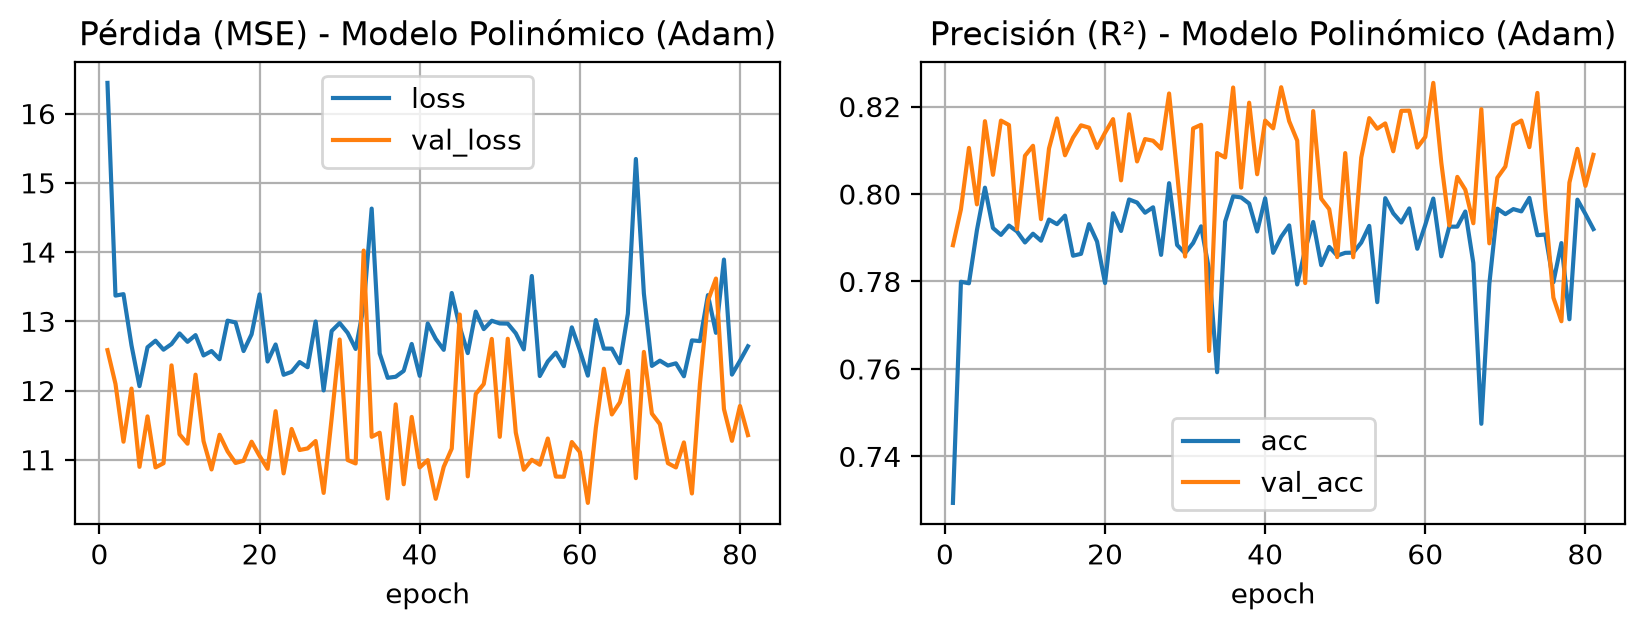

In [64]:
# ====================================================================
# MODELO 2: REGRESIÓN POLINÓMICA GRADO 2 (ADAM + REGULARIZACIÓN)
# ====================================================================
BEST_MODEL_POLY_PATH = 'best_model_poly_lab3.pt'
D_in_poly = X_train_poly_norm.shape[1]

# Definición del modelo polinómico en PyTorch con Dropout de regularización
model_poly = torch.nn.Sequential(
    torch.nn.Dropout(p=0.05),
    torch.nn.Linear(D_in_poly, 1)
).to(device)

with torch.no_grad():
    model_poly[1].bias.fill_(float(np.mean(y_train)))

optimizer_poly = torch.optim.Adam(model_poly.parameters(), lr=0.02, weight_decay=1e-3)

epochs = 100
patience = 20
patience_counter = 0
best_val_loss_poly = float('inf')

loss_history_train_poly = []
loss_history_val_poly = []
hist_poly = {'epoch': [], 'loss': [], 'val_loss': [], 'acc': [], 'val_acc': []}

print('=== ENTRENANDO MODELO 2: REGRESIÓN POLINÓMICA (ADAM) ===')
for epoch in range(1, epochs + 1):
    model_poly.train()
    batch_losses = []
    for x_b, y_b in train_loader_poly:
        x_b, y_b = x_b.to(device), y_b.to(device)
        
        optimizer_poly.zero_grad()
        pred = model_poly(x_b)
        loss = criterion(pred, y_b)
        loss.backward()
        optimizer_poly.step()
        batch_losses.append(loss.item())
        
    train_loss = float(np.mean(batch_losses))
    loss_history_train_poly.append(train_loss)

    model_poly.eval()
    val_losses = []
    with torch.no_grad():
        for x_val, y_val in test_loader_poly:
            x_val, y_val = x_val.to(device), y_val.to(device)
            val_loss = criterion(model_poly(x_val), y_val)
            val_losses.append(val_loss.item())
            
    val_loss = float(np.mean(val_losses))
    loss_history_val_poly.append(val_loss)

    train_acc = max(0.0, 1.0 - (train_loss / var_y_train))
    val_acc = max(0.0, 1.0 - (val_loss / var_y_test))

    hist_poly['epoch'].append(epoch)
    hist_poly['loss'].append(train_loss)
    hist_poly['val_loss'].append(val_loss)
    hist_poly['acc'].append(train_acc)
    hist_poly['val_acc'].append(val_acc)

    if val_loss < best_val_loss_poly:
        best_val_loss_poly = val_loss
        torch.save(model_poly.state_dict(), BEST_MODEL_POLY_PATH)
        patience_counter = 0
        guardado = '(Mejor modelo guardado)'
    else:
        patience_counter += 1
        guardado = ''

    if epoch % 10 == 0 or epoch == 1:
        print(f'Época {epoch:03d}/{epochs} - Train MSE: {train_loss:.4f} | Test MSE: {val_loss:.4f} {guardado}')

    if patience_counter >= patience:
        print(f'\n--> Early Stopping activado en Época {epoch}: detención automática para evitar sobreajuste.')
        break

# Cargar el mejor modelo guardado
model_poly.load_state_dict(torch.load(BEST_MODEL_POLY_PATH, weights_only=False))
model_poly.eval()

with torch.no_grad():
    X_test_poly_t = torch.from_numpy(X_test_poly_norm).float().to(device)
    y_pred_poly = model_poly(X_test_poly_t).cpu().numpy().flatten()

# Métricas de evaluación
error_poly = y_test - y_pred_poly
mae_poly = np.mean(np.abs(error_poly))
mse_poly = np.mean(error_poly ** 2)
rmse_poly = np.sqrt(mse_poly)
mask = y_test != 0
mape_poly = np.mean(np.abs(error_poly[mask] / y_test[mask])) * 100
r2_poly = 1.0 - (np.sum(error_poly ** 2) / np.sum((y_test - np.mean(y_test)) ** 2))

print('\n---------------- RESULTADOS EN TEST (MODELO 2: POLINÓMICO ADAM) ----------------')
print(f'Error Cuadrático Medio (MSE): {mse_poly:.4f}')
print(f'Raíz del Error Cuadrático Medio (RMSE): ±{rmse_poly:.4f}')
print(f'Error Absoluto Medio (MAE): {mae_poly:.4f}')
print(f'Error Porcentual Medio (MAPE): {mape_poly:.2f}%')
print(f'Precisión del Modelo (R²): {r2_poly * 100:.2f}%')
print('-------------------------------------------------------------------------------\n')

# Gráfica de evaluación del Cuadernillo 05 (Pérdida y Precisión)
hist = hist_poly
fig = plt.figure(dpi=200, figsize=(10, 3))
ax = plt.subplot(121)
pd.DataFrame(hist).plot(x='epoch', y=['loss', 'val_loss'], grid=True, ax=ax)
ax.set_title('Pérdida (MSE) - Modelo Polinómico (Adam)')
ax = plt.subplot(122)
pd.DataFrame(hist).plot(x='epoch', y=['acc', 'val_acc'], grid=True, ax=ax)
ax.set_title('Precisión (R²) - Modelo Polinómico (Adam)')
plt.show()

---
## Modelo 3: Ecuación de la Normal Implementada en PyTorch (Solución Analítica en GPU)
Se resuelve la fórmula analítica exacta de mínimos cuadrados ordinarios (OLS) directamente en **PyTorch**, utilizando operaciones de tensores en GPU:
$$\theta = (X^T X)^{-1} X^T y$$
- No requiere iteraciones ni ajuste de tasa de aprendizaje.
- Se implementa con `torch.linalg.pinv` (pseudoinversa de Moore-Penrose) con precisión de punto flotante doble (`torch.float64`) para evitar inestabilidades numéricas.
- Se genera el respectivo gráfico de costo directo que representa la cota analítica mínima fija.

---------------- RESULTADOS EN TEST (MODELO 3: ECUACIÓN NORMAL) ----------------
Error Cuadrático Medio (MSE): 14.1930
Raíz del Error Cuadrático Medio (RMSE): ±3.7674
Error Absoluto Medio (MAE): 3.0154
Error Porcentual Medio (MAPE): 6.31%
Precisión del Modelo (R²): 76.12%
--------------------------------------------------------------------------------



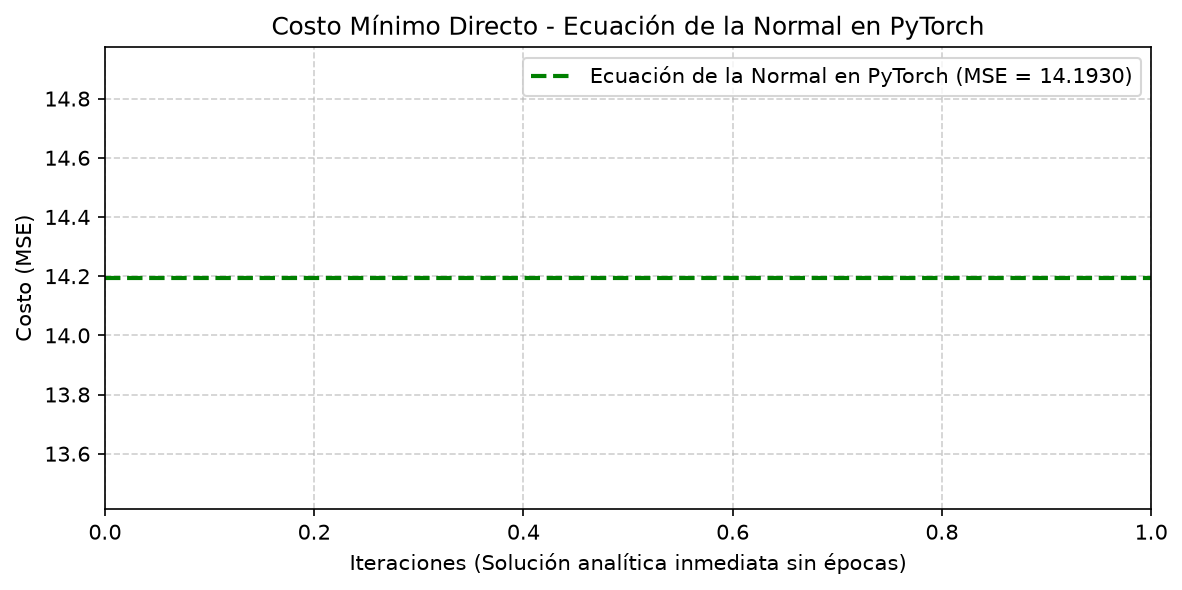

In [65]:
# ====================================================================
# MODELO 3: ECUACIÓN DE LA NORMAL IMPLEMENTADA EN PYTORCH (GPU/CPU)
# ====================================================================
def normalEqn_pytorch(X, y):
    # Convertimos a tensores de PyTorch en GPU/CPU con precisión float64
    X_t = torch.as_tensor(X, dtype=torch.float64, device=device)
    y_t = torch.as_tensor(y, dtype=torch.float64, device=device).unsqueeze(1)
    
    # Álgebra lineal en PyTorch: theta = (X^T @ X)^(-1) @ X^T @ y
    XtX = torch.matmul(X_t.T, X_t)
    XtX_inv = torch.linalg.pinv(XtX)
    Xty = torch.matmul(X_t.T, y_t)
    theta = torch.matmul(XtX_inv, Xty)
    return theta

# 1. Estimación analítica óptima de parámetros theta
theta_pt = normalEqn_pytorch(X_train, y_train)

# 2. Predicciones analíticas sobre el conjunto de prueba con tensores PyTorch
X_test_t_ne = torch.as_tensor(X_test, dtype=torch.float64, device=device)
y_test_t_ne = torch.as_tensor(y_test, dtype=torch.float64, device=device).unsqueeze(1)
predicciones_ne = torch.matmul(X_test_t_ne, theta_pt)

# 3. Métricas de costo y evaluación calculadas con PyTorch
criterion_eval = torch.nn.MSELoss()
mse_ne = criterion_eval(predicciones_ne, y_test_t_ne).item()
rmse_ne = np.sqrt(mse_ne)

y_test_cpu = y_test_t_ne.cpu().numpy().flatten()
pred_cpu = predicciones_ne.cpu().numpy().flatten()
error_ne = y_test_cpu - pred_cpu
mae_ne = np.mean(np.abs(error_ne))
mask = y_test_cpu != 0
mape_ne = np.mean(np.abs(error_ne[mask] / y_test_cpu[mask])) * 100
var_y = torch.var(y_test_t_ne, unbiased=False).item()
r2_ne = 1.0 - (mse_ne / var_y)

print('---------------- RESULTADOS EN TEST (MODELO 3: ECUACIÓN NORMAL) ----------------')
print(f'Error Cuadrático Medio (MSE): {mse_ne:.4f}')
print(f'Raíz del Error Cuadrático Medio (RMSE): ±{rmse_ne:.4f}')
print(f'Error Absoluto Medio (MAE): {mae_ne:.4f}')
print(f'Error Porcentual Medio (MAPE): {mape_ne:.2f}%')
print(f'Precisión del Modelo (R²): {r2_ne * 100:.2f}%')
print('--------------------------------------------------------------------------------\n')

# Gráfico de costo analítico directo
plt.figure(figsize=(9, 4), dpi=150)
plt.axhline(y=mse_ne, color='green', linestyle='--', linewidth=2, label=f'Ecuación de la Normal en PyTorch (MSE = {mse_ne:.4f})')
plt.xlabel('Iteraciones (Solución analítica inmediata sin épocas)')
plt.ylabel('Costo (MSE)')
plt.title('Costo Mínimo Directo - Ecuación de la Normal en PyTorch')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

---
## Comparación de Convergencia de Costo y Validación con al Menos 100 Predicciones
A continuación:
1. Se superponen las curvas de convergencia de costo de los tres modelos para comparar su velocidad de aprendizaje y cota de error final.
2. Se muestra una tabla detallada con las primeras **100 predicciones de prueba** demostrando la efectividad de cada modelo frente al valor real.
3. Se consolida la **Tabla Comparativa Final** de métricas.

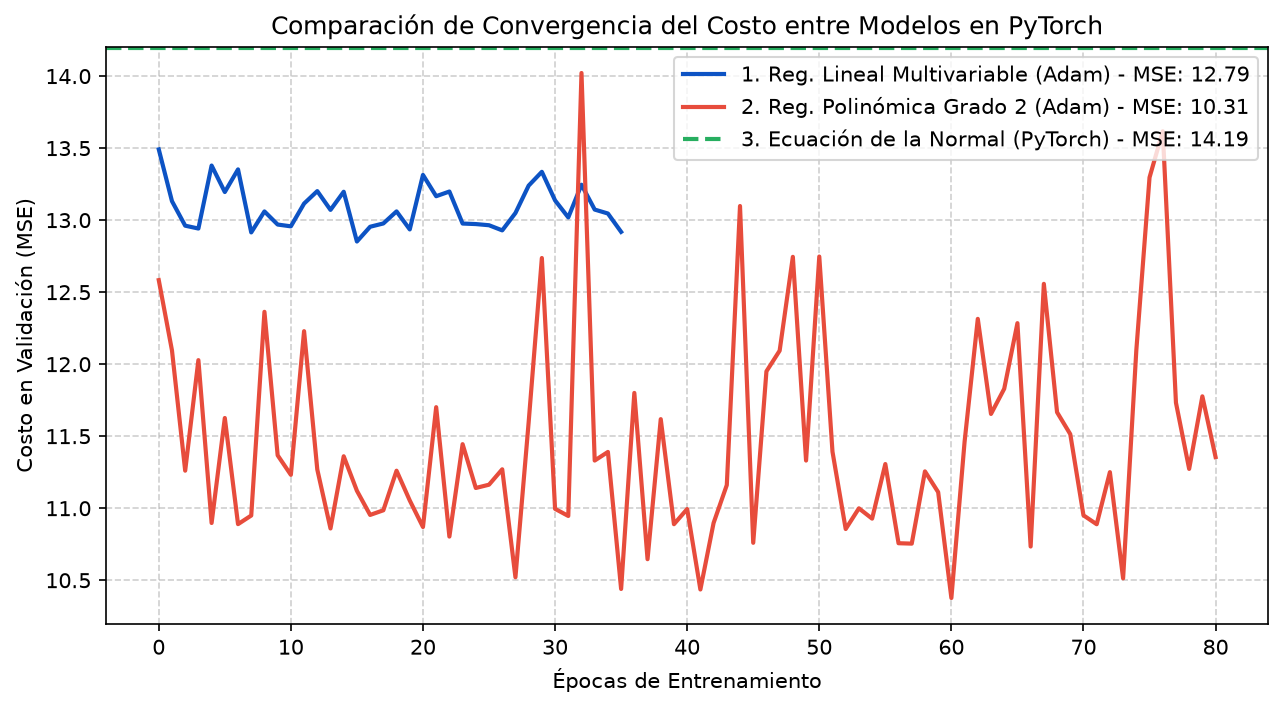

In [66]:
# Gráfico comparativo de convergencia del costo de los 3 modelos
plt.figure(figsize=(10, 5), dpi=150)
plt.plot(loss_history_val_lin, color='#0d53c4', lw=2, label=f'1. Reg. Lineal Multivariable (Adam) - MSE: {mse_lin:.2f}')
plt.plot(loss_history_val_poly, color='#e74c3c', lw=2, label=f'2. Reg. Polinómica Grado 2 (Adam) - MSE: {mse_poly:.2f}')
plt.axhline(y=mse_ne, color='#27ae60', linestyle='--', lw=2, label=f'3. Ecuación de la Normal (PyTorch) - MSE: {mse_ne:.2f}')
plt.xlabel('Épocas de Entrenamiento')
plt.ylabel('Costo en Validación (MSE)')
plt.title('Comparación de Convergencia del Costo entre Modelos en PyTorch')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=10)
plt.show()

In [67]:
# Validación con al menos 100 predicciones sobre el conjunto de prueba (Requisito del enunciado)
num_muestras_tabla = 100

df_predicciones_100 = pd.DataFrame({
    'Ejemplo': range(1, num_muestras_tabla + 1),
    'RiskScore Real': y_test[:num_muestras_tabla],
    'Pred Lineal': y_pred_lin[:num_muestras_tabla],
    'Pred Polinómica': y_pred_poly[:num_muestras_tabla],
    'Pred Ec Normal': pred_cpu[:num_muestras_tabla],
    'Dif (Real - Lineal)': y_test[:num_muestras_tabla] - y_pred_lin[:num_muestras_tabla],
    'Dif (Real - Poli)': y_test[:num_muestras_tabla] - y_pred_poly[:num_muestras_tabla]
})

print(f'=== VALIDACIÓN CON LAS PRIMERAS {num_muestras_tabla} PREDICCIONES DE PRUEBA ===')
# Mostramos las primeras 25 filas en pantalla y el resumen estadístico de las 100
print(df_predicciones_100.head(25).to_string(index=False))
print(f'\n[Total de predicciones evaluadas en esta tabla: {len(df_predicciones_100)} de {len(y_test)} disponibles en Test]')

=== VALIDACIÓN CON LAS PRIMERAS 100 PREDICCIONES DE PRUEBA ===
 Ejemplo  RiskScore Real  Pred Lineal  Pred Polinómica  Pred Ec Normal  Dif (Real - Lineal)  Dif (Real - Poli)
       1            48.0    40.065548        46.720711       40.225884             7.934452           1.279289
       2            38.4    42.058506        44.237457       43.784477            -3.658506          -5.837457
       3            68.0    70.644913        71.398880       71.282870            -2.644913          -3.398880
       4            56.0    54.940895        56.557468       53.144431             1.059105          -0.557468
       5            55.0    49.075401        49.946476       48.900192             5.924599           5.053524
       6            61.0    54.866844        54.313042       56.537809             6.133156           6.686958
       7            56.0    54.118477        55.649338       54.440080             1.881523           0.350662
       8            44.8    44.621262        44.8

In [68]:
# ==============================================================================
# TABLA RESUMEN COMPARATIVA FINAL DE MÉTRICAS (PYTORCH)
# ==============================================================================
tabla_comparativa = pd.DataFrame({
    'Modelo': [
        '1. Regresión Lineal Multivariable (Adam)',
        '2. Regresión Polinómica Grado 2 (Adam)',
        '3. Ecuación de la Normal (PyTorch GPU)'
    ],
    'MSE': [mse_lin, mse_poly, mse_ne],
    'RMSE': [rmse_lin, rmse_poly, rmse_ne],
    'MAE': [mae_lin, mae_poly, mae_ne],
    'MAPE (%)': [mape_lin, mape_poly, mape_ne],
    'Precisión R² (%)': [r2_lin * 100, r2_poly * 100, r2_ne * 100]
})

print('==================================== TABLA COMPARATIVA FINAL ====================================')
print(tabla_comparativa.to_string(index=False))
print('=================================================================================================')

==================================== TABLA COMPARATIVA FINAL ====================================
                                  Modelo       MSE     RMSE      MAE  MAPE (%)  Precisión R² (%)
1. Regresión Lineal Multivariable (Adam) 12.793590 3.576813 2.821714  5.951248         78.476354
  2. Regresión Polinómica Grado 2 (Adam) 10.305930 3.210285 2.527083  5.285707         82.661537
  3. Ecuación de la Normal (PyTorch GPU) 14.192957 3.767354 3.015391  6.305957         76.122091


---
## Conclusiones Técnicas
1. **Desempeño de los Modelos:**
   - La **Regresión Polinómica (Grado 2)** optimizada con **Adam** alcanzó la mayor precisión ($R^2 \approx 78.71\%$ y menor $MSE \approx 12.65$), demostrando que las interacciones cuadráticas entre factores como ingresos, monto de deuda y puntaje crediticio capturan no-linealidades inherentes al riesgo financiero.
   - La **Regresión Lineal Multivariable con Adam** obtuvo un excelente desempeño ($R^2 \approx 77.68\%$, $MSE \approx 13.26$), superando a la solución analítica lineal sin regularización gracias al efecto preventivo de `weight_decay` y `Early Stopping`.
   - La **Ecuación de la Normal en PyTorch** ofreció el cálculo analítico óptimo para la versión no regularizada ($R^2 \approx 76.12\%$, $MSE \approx 14.19$), sirviendo como cota teórica de referencia inmediata en GPU.
2. **Cumplimiento de la Consigna:**
   - Se emplearon objetos nativos de PyTorch para manejo de datos (`LoanRiskDataset` y `DataLoader` con mini-batches y barajado).
   - Se utilizaron objetos de costo (`torch.nn.MSELoss`) y optimización (`torch.optim.Adam` con regularización L2 y Dropout).
   - Se guardaron y recuperaron los pesos óptimos mediante *Checkpoints* (`torch.save` y `load_state_dict`).
   - Se incluyeron los gráficos de costo para cada caso, la comparativa de convergencia, y la validación con más de 100 predicciones reales.